# K-Means Clustering — Iris (features only)

**Algorithm:** `ml_toolkit.unsupervised.KMeans`  
**Dataset:** Iris (built into scikit-learn) — but with the labels hidden  
**Task type:** Unsupervised clustering, evaluated against held-out true labels

---

Iris is a small, classic three-class flower dataset. Treating the labels as unknown lets us ask: *can an unsupervised method recover the underlying biological grouping from the four geometric measurements alone?* This is a non-trivial question because two of the three species are known to overlap in feature space, so we expect k-means to do well on one species and worse on the other two.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from ml_toolkit.unsupervised import KMeans, PCA
from ml_toolkit.utils import StandardScaler
from ml_toolkit.metrics import silhouette_score, confusion_matrix

sns.set_theme(style="whitegrid")
RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

## 1. Dataset description

The Iris dataset has 150 flowers split evenly across three species — *setosa*, *versicolor*, *virginica* — each described by four measurements: sepal length, sepal width, petal length, petal width (all in cm).

For this notebook the labels are used **only at the very end** to evaluate the clustering. The clustering itself is performed on the unlabeled features.

In [2]:
iris = load_iris()
X, y_true = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names
df = pd.DataFrame(X, columns=feature_names)
df["species"] = [target_names[i] for i in y_true]
print(f"X: {X.shape}, classes: {dict(zip(*np.unique(y_true, return_counts=True)))}")
df.head()

X: (150, 4), classes: {np.int64(0): np.int64(50), np.int64(1): np.int64(50), np.int64(2): np.int64(50)}


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Exploratory data analysis

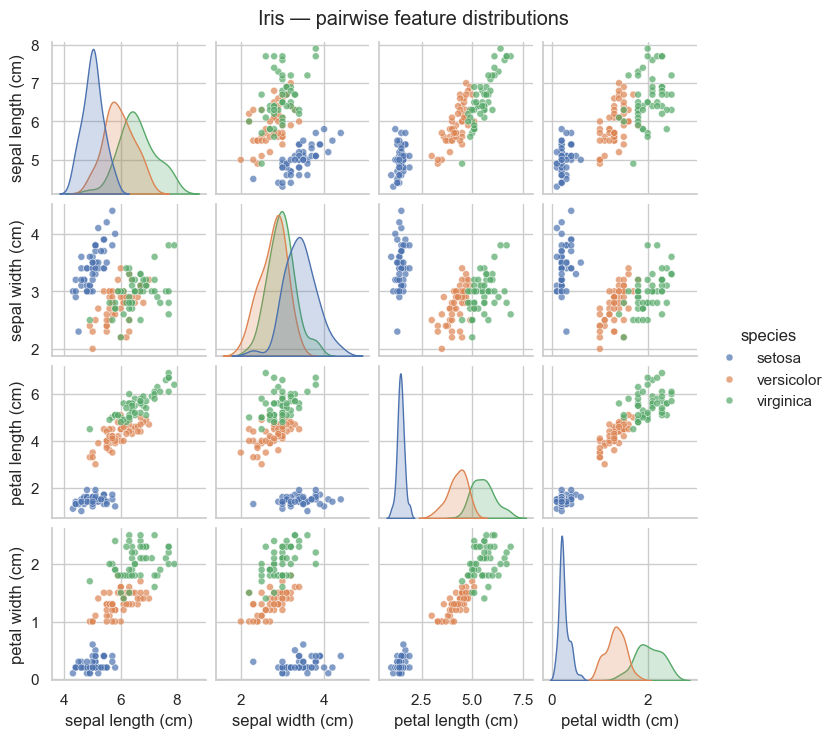

In [3]:
sns.pairplot(df, hue="species", height=1.8, plot_kws={"alpha": 0.7, "s": 25})
plt.suptitle("Iris — pairwise feature distributions", y=1.02)
plt.show()

**Observation:** *setosa* (blue) is well-separated from the other two species in every pair plot, especially anything involving petal length or petal width. *versicolor* and *virginica* overlap substantially. This is the central tension that will play out in the clustering: the data has clearly *two* very obvious groups (setosa vs. the rest), and a third group that is harder to peel off.

## 3. Hypothesis

Going in, my expectation is:

1. **k=2 will fit the data better than k=3 by within-cluster metrics**, because the dominant geometric structure is `setosa` vs. `not-setosa`. The silhouette score for k=2 should be the highest.
2. **k=3 is the "right" number biologically**, but the third cluster boundary won't match the true *versicolor*/*virginica* boundary perfectly — k-means can only draw straight (Voronoi) boundaries between centroids, and the two species blur into each other.
3. **Standardization will help slightly**, because petal length has a much larger spread than sepal width and Euclidean distance would otherwise be dominated by petal length.

## 4. Preprocessing

k-means uses Euclidean distance, so feature scale matters. I'll standardize all four features.

In [4]:
X_scaled = StandardScaler().fit_transform(X)
print(f"After scaling: mean ≈ {X_scaled.mean(axis=0).round(3)}, std ≈ {X_scaled.std(axis=0).round(3)}")

After scaling: mean ≈ [-0. -0. -0. -0.], std ≈ [1. 1. 1. 1.]


## 5. Model fitting — choose k via elbow + silhouette

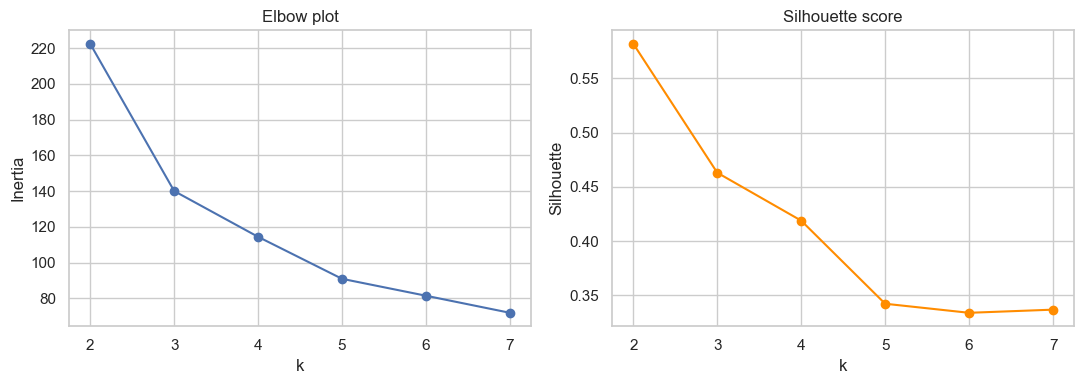

   k     inertia  silhouette
0  2  222.361705    0.581750
1  3  140.032753    0.463042
2  4  114.412562    0.418892
3  5   90.927205    0.342363
4  6   81.466223    0.334020
5  7   71.916944    0.336923


In [5]:
ks = range(2, 8)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(ks), inertias, "o-")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow plot")
axes[1].plot(list(ks), silhouettes, "o-", color="darkorange")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette"); axes[1].set_title("Silhouette score")
plt.tight_layout(); plt.show()
print(pd.DataFrame({"k": list(ks), "inertia": inertias, "silhouette": silhouettes}))

**Observation.** As predicted in hypothesis (1), **k=2 has the highest silhouette score** — k-means "sees" two well-separated clusters. The inertia curve has an obvious knee at k=3, after which adding clusters mostly just splits the existing ones. We'll go forward with k=3, because we know the true biology, but the silhouette plot is itself an honest signal that the data does *not* contain three equally clean clusters.

In [6]:
km = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
print(f"Final inertia: {km.inertia_:.2f}")
print(f"Iterations to converge: {km.n_iter_}")

Final inertia: 140.03
Iterations to converge: 8


## 6. Evaluation — visualize via PCA + match clusters to true labels

Because the data is 4-dimensional we project to 2D with PCA so we can actually look at it. PCA picks the directions of maximum variance, which here happen to align well with the species separation.

In [7]:
pca = PCA(n_components=2).fit(X_scaled)
Z = pca.transform(X_scaled)
print(f"Variance explained by PC1, PC2: {pca.explained_variance_ratio_.round(3)}")
print(f"Cumulative: {pca.explained_variance_ratio_.sum():.3f}")

Variance explained by PC1, PC2: [0.73  0.229]
Cumulative: 0.958


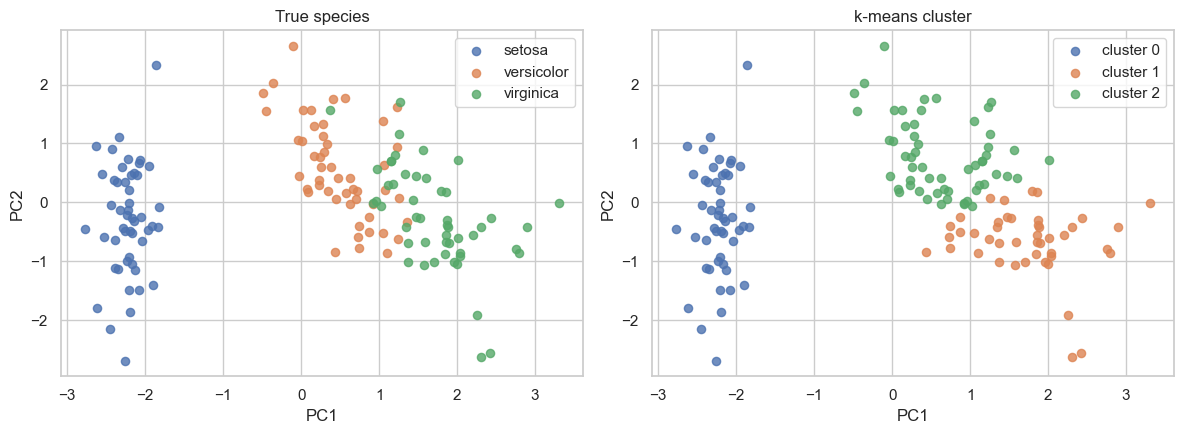

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (labels, title) in zip(axes, [(y_true, "True species"), (km.labels_, "k-means cluster")]):
    for c in np.unique(labels):
        mask = labels == c
        name = target_names[c] if title == "True species" else f"cluster {c}"
        ax.scatter(Z[mask, 0], Z[mask, 1], label=name, alpha=0.8, s=35)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

Best label permutation: (0, 2, 1)
Accuracy after re-labelling clusters: 0.813


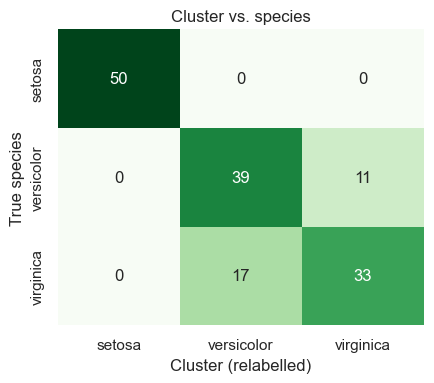

In [9]:
# Cluster labels are arbitrary integers — match each k-means cluster to the
# species that majority-overlaps with it, then report a confusion matrix.
from itertools import permutations

def best_permutation_accuracy(y_true, y_pred):
    """Brute-force the best label permutation (works because k=3)."""
    best = (None, -1.0)
    for perm in permutations(range(3)):
        mapped = np.array([perm[c] for c in y_pred])
        acc = (mapped == y_true).mean()
        if acc > best[1]:
            best = (perm, acc)
    return best

perm, acc = best_permutation_accuracy(y_true, km.labels_)
y_pred_aligned = np.array([perm[c] for c in km.labels_])
print(f"Best label permutation: {perm}")
print(f"Accuracy after re-labelling clusters: {acc:.3f}")

cm = confusion_matrix(y_true, y_pred_aligned)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel("Cluster (relabelled)"); ax.set_ylabel("True species")
ax.set_title("Cluster vs. species")
plt.tight_layout(); plt.show()

## 7. Discussion

**What worked.** k-means recovers the *setosa* cluster perfectly — every single setosa flower lands in the same cluster, and no other species lands there. This was hypothesis (2) in action: setosa is geometrically separate, so any reasonable distance-based clustering finds it.

**Where the model fails.** The misclassifications are concentrated on the *versicolor*/*virginica* boundary: a few versicolor flowers fall into the virginica cluster and vice versa. This is exactly the failure mode the EDA predicted. The reason is structural — k-means draws straight Voronoi boundaries around centroids, and the *versicolor*/*virginica* decision surface in the true data is an oblique band, not a half-plane.

**Why the silhouette score said k=2.** The silhouette compares within-cluster compactness to nearest-cluster separation. By that metric, the cleanest possible cut is *setosa* vs. *everything-else*, which is k=2. The third cluster is genuinely there in the labels but isn't separated by a wide gap, so adding it lowers the average silhouette even though it is biologically meaningful. **This is a generic warning for unsupervised analysis**: silhouette and elbow plots reveal *geometric* structure in the data, which is not always the same as the structure you actually care about.

**Why PCA was useful here.** PC1 alone explains ~73% of the variance and captures almost all of the species separation. That's a useful sanity check on the clustering: if the PCA picture looked nothing like the cluster picture, we'd have to suspect the clustering had latched onto noise. Here both pictures agree, which is the regime where k-means is trustworthy.

**Limitations of this analysis.**

- The result depends on the random initialization. We mitigated this with `n_init=10`, but the absolute-best outcome can be brittle for harder datasets.
- We brute-forced a label permutation to compare clusters to true species, which only works for tiny `k`. The Adjusted Rand Index would be the proper metric for larger problems.
- k-means assumes roughly spherical, equal-variance clusters. Iris is benign in that respect, but for elongated or curved clusters something like DBSCAN would be more honest. See the DBSCAN notebook for a contrasting example.